### Importación de datos



In [8]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [11]:
import matplotlib.pyplot as plt

#1. Análisis de facturación



In [9]:
def suma_x_tienda(td):
  return td['Precio'].sum()

sum_t1 = suma_x_tienda(tienda)
sum_t2 = suma_x_tienda(tienda2)
sum_t3 = suma_x_tienda(tienda3)
sum_t4 = suma_x_tienda(tienda4)

print('Total de Ventas en la tienda 1: ', int(sum_t1))
print('Total de Ventas en la tienda 2: ', int(sum_t2))
print('Total de Ventas en la tienda 3: ', int(sum_t3))
print('Total de Ventas en la tienda 4: ', int(sum_t4))

Total de Ventas en la tienda 1:  1150880400
Total de Ventas en la tienda 2:  1116343500
Total de Ventas en la tienda 3:  1098019600
Total de Ventas en la tienda 4:  1038375700


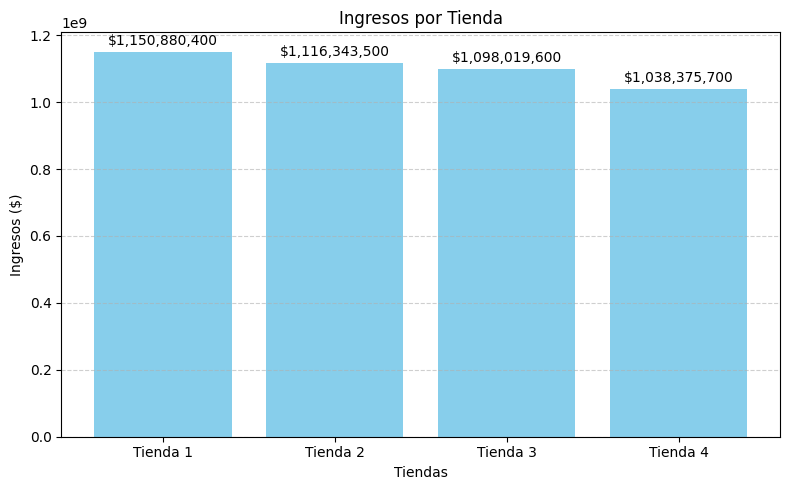

In [10]:
# Datos de las tiendas
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos_por_tienda = [sum_t1, sum_t2, sum_t3, sum_t4]

# Crear figura del gráfico
plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_tiendas, ingresos_por_tienda, color='#87CEEB')

# Agregar título y etiquetas
plt.title('Ingresos por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Ingresos ($)')

# Cuadrícula en el eje Y
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Mostrar el ingreso sobre cada barra
for indice, ingreso in enumerate(ingresos_por_tienda):
    posicion_x = indice
    posicion_y = ingreso + max(ingresos_por_tienda) * 0.01
    texto = f"${int(ingreso):,}"

    plt.text(posicion_x, posicion_y, texto, ha='center', va='bottom', fontsize=10)

#  Mostrar gráfico completo
plt.tight_layout()
plt.show()



# 2. Ventas por categoría

In [12]:
# función para contar las categorias mas comunes en un dataFrame
def contar_categorias(df, top_n=5):
  conteo = df['Categoria del Producto'].value_counts().head(top_n)
  print("Top", top_n , "Categoria más vendidas:")
  print(conteo)
  return conteo

# Función para obtener la lista de categorías únicas de una tienda
def listar_categorias(df):
  categorias = df['Categoría del Producto'].dropna().unique().tolist()
  print("Lista de categorías:")
  print(categorias)
  return categorias

# Lista de tiendas (DataFrame)
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Recorrer cada tienda y mostrar sus categorías
for i, tienda_df in enumerate(tiendas, start=1):
  print(f"\nAnálisis de la tienda {i}:")
  listar_categorias(tienda_df)


Análisis de la tienda 1:
Lista de categorías:
['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos', 'Artículos para el hogar', 'Deportes y diversión', 'Libros', 'Instrumentos musicales']

Análisis de la tienda 2:
Lista de categorías:
['Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Artículos para el hogar', 'Juguetes', 'Electrodomésticos', 'Libros']

Análisis de la tienda 3:
Lista de categorías:
['Electrodomésticos', 'Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Juguetes', 'Artículos para el hogar', 'Libros']

Análisis de la tienda 4:
Lista de categorías:
['Electrodomésticos', 'Muebles', 'Deportes y diversión', 'Libros', 'Electrónicos', 'Instrumentos musicales', 'Juguetes', 'Artículos para el hogar']


In [16]:
# Función para obtener categorías únicas
def obtener_categorias_unicas(df):
    return df['Categoría del Producto'].dropna().unique().tolist()

# Función para contar productos por categoría
def contar_productos_por_categoria(df):
    return df['Categoría del Producto'].value_counts().to_dict()

# Lista de tiendas y nombres
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Recorrer cada tienda
for nombre, df in zip(nombres, tiendas):
    print(f"\n Análisis de {nombre}:")

    categorias = obtener_categorias_unicas(df)
    print("Categorías únicas:", categorias)

    conteo = contar_productos_por_categoria(df)
    print("Cantidad por categoría:", conteo)



 Análisis de Tienda 1:
Categorías únicas: ['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos', 'Artículos para el hogar', 'Deportes y diversión', 'Libros', 'Instrumentos musicales']
Cantidad por categoría: {'Muebles': 465, 'Electrónicos': 448, 'Juguetes': 324, 'Electrodomésticos': 312, 'Deportes y diversión': 284, 'Instrumentos musicales': 182, 'Libros': 173, 'Artículos para el hogar': 171}

 Análisis de Tienda 2:
Categorías únicas: ['Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Artículos para el hogar', 'Juguetes', 'Electrodomésticos', 'Libros']
Cantidad por categoría: {'Muebles': 442, 'Electrónicos': 422, 'Juguetes': 313, 'Electrodomésticos': 305, 'Deportes y diversión': 275, 'Instrumentos musicales': 224, 'Libros': 197, 'Artículos para el hogar': 181}

 Análisis de Tienda 3:
Categorías únicas: ['Electrodomésticos', 'Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Juguetes', 'Artículos para el hogar', 'Libros']
Can

In [13]:
def categorias_tiendas(td):
    return list(td['Categoría del Producto'].unique())

categorias_T1 = categorias_tiendas(tienda)
categorias_T2 = categorias_tiendas(tienda2)
categorias_T3 = categorias_tiendas(tienda3)
categorias_T4 = categorias_tiendas(tienda4)

print(categorias_T1)
print(categorias_T2)
print(categorias_T3)
print(categorias_T4)

def cantidad_x_categorias(tienda):
    return tienda['Categoría del Producto'].value_counts().to_dict()

cant_t1 = cantidad_x_categorias(tienda)
cant_t2 = cantidad_x_categorias(tienda2)
cant_t3 = cantidad_x_categorias(tienda3)
cant_t4 = cantidad_x_categorias(tienda4)

print(cant_t1)
print(cant_t2)
print(cant_t3)
print(cant_t4)

['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos', 'Artículos para el hogar', 'Deportes y diversión', 'Libros', 'Instrumentos musicales']
['Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Artículos para el hogar', 'Juguetes', 'Electrodomésticos', 'Libros']
['Electrodomésticos', 'Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Juguetes', 'Artículos para el hogar', 'Libros']
['Electrodomésticos', 'Muebles', 'Deportes y diversión', 'Libros', 'Electrónicos', 'Instrumentos musicales', 'Juguetes', 'Artículos para el hogar']
{'Muebles': 465, 'Electrónicos': 448, 'Juguetes': 324, 'Electrodomésticos': 312, 'Deportes y diversión': 284, 'Instrumentos musicales': 182, 'Libros': 173, 'Artículos para el hogar': 171}
{'Muebles': 442, 'Electrónicos': 422, 'Juguetes': 313, 'Electrodomésticos': 305, 'Deportes y diversión': 275, 'Instrumentos musicales': 224, 'Libros': 197, 'Artículos para el hogar': 181}
{'Muebles': 499, 'Electrónicos':

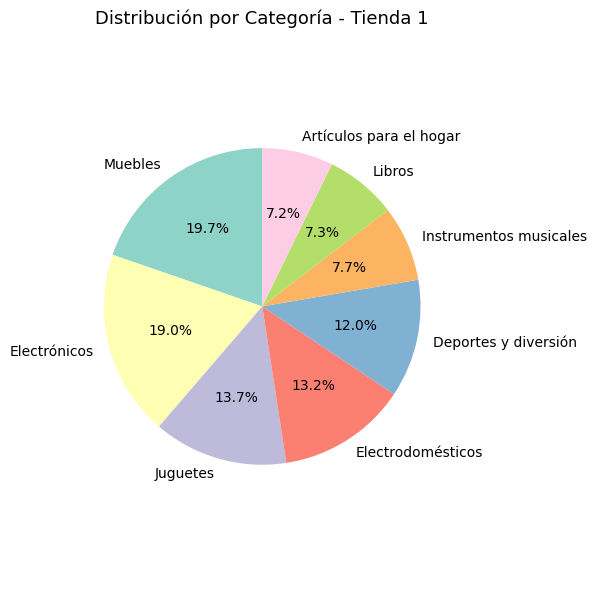

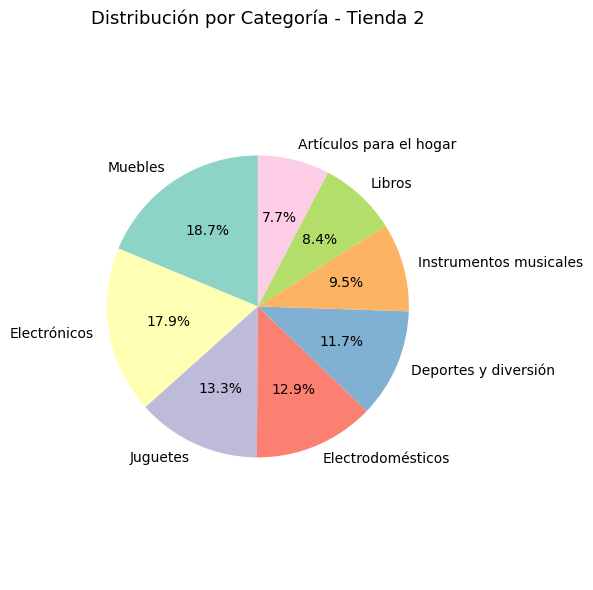

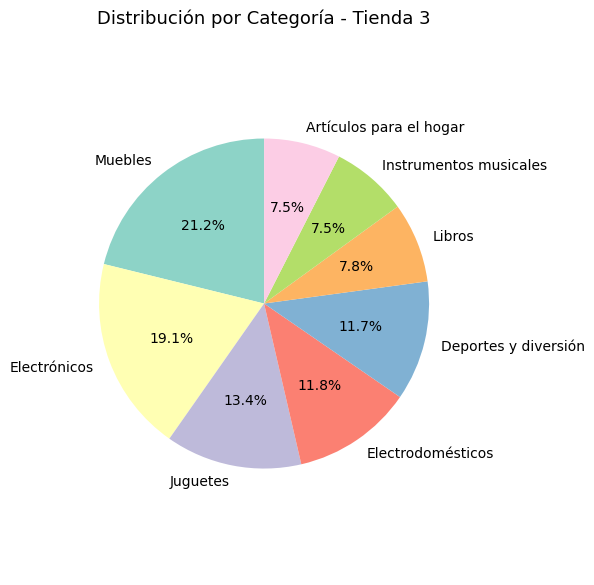

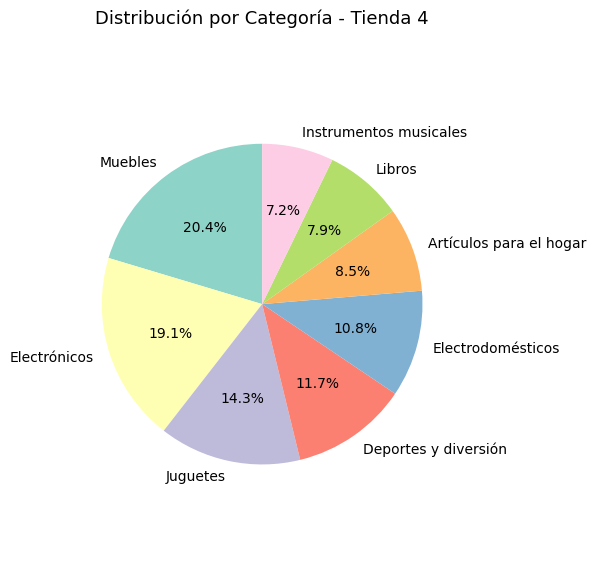

In [15]:
# Lista de diccionarios con los conteos por categoría por tienda
conteos_por_tienda = [
    tienda['Categoría del Producto'].value_counts().to_dict()
    for tienda in [tienda, tienda2, tienda3, tienda4]
]

# Nombres para las tiendas
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Generar un gráfico circular para cada tienda
for nombre, conteo in zip(nombres_tiendas, conteos_por_tienda):
    plt.figure(figsize=(6, 6))  # Crear nueva figura de tamaño 6x6
    plt.pie(
        conteo.values(),             # Valores de los productos por categoría
        labels=conteo.keys(),        # Etiquetas (nombres de categorías)
        autopct='%1.1f%%',           # Mostrar porcentaje con 1 decimal
        startangle=90,               # Iniciar desde arriba
        colors=plt.cm.Set3.colors    # Paleta de colores agradable
    )
    plt.title(f'Distribución por Categoría - {nombre}', fontsize=13)
    plt.axis('equal')  # Mantiene proporciones de círculo
    plt.tight_layout()  # Ajusta el gráfico automáticamente
    plt.show()  # Mostrar gráfico


# 3. Calificación promedio de la tienda


In [20]:
# Lista de DataFrames y nombres para impresión
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Mostrar cuántos valores nulos hay en la columna 'Calificación' por tienda
for nombre, df in zip(nombres, tiendas):
    nulos = df['Calificación'].isnull().sum()
    print(f"{nombre} - valores nulos en la columna 'Calificación': {nulos}")


Tienda 1 - valores nulos en la columna 'Calificación': 0
Tienda 2 - valores nulos en la columna 'Calificación': 0
Tienda 3 - valores nulos en la columna 'Calificación': 0
Tienda 4 - valores nulos en la columna 'Calificación': 0


In [24]:
# Función para obtener el promedio de calificación
def obtener_calificacion_promedio(df):
  return df['Calificación'].mean()

# lista de DataFrames y sus nombres
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Calcular y mostrar el promedio de calificación por tienda
for nombre, tienda_df in zip(nombres_tiendas, tiendas):
  promedio = obtener_calificacion_promedio(tienda_df)
  print(f"{nombre} - Promedio de Calificación: {promedio:.2f}")

Tienda 1 - Promedio de Calificación: 3.98
Tienda 2 - Promedio de Calificación: 4.04
Tienda 3 - Promedio de Calificación: 4.05
Tienda 4 - Promedio de Calificación: 4.00


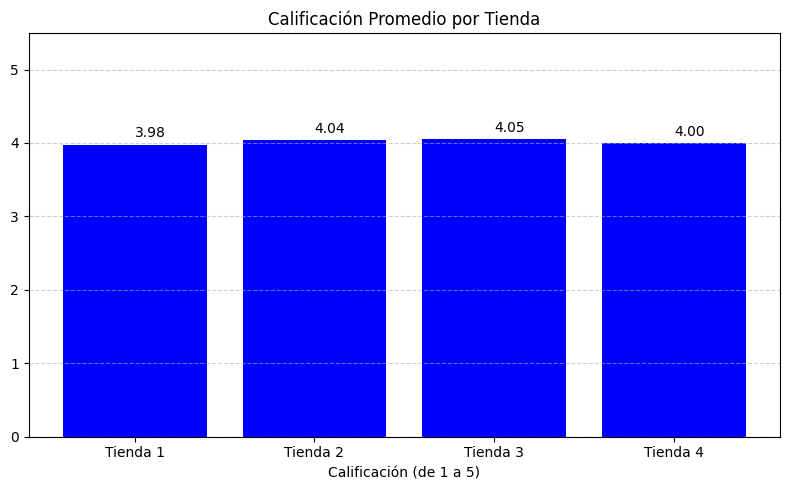

In [31]:
calificaciones = [calif_t1, calif_t2, calif_t3, calif_t4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_tiendas, calificaciones, color='blue')

for i, barra in enumerate(barras):
  altura = barra.get_height()
  plt.text(barra.get_x() + barra.get_width() / 2, altura + 0.1, f'{calificaciones[i]:.2f}')

plt.title('Calificación Promedio por Tienda')
plt.xlabel('Calificación (de 1 a 5)')
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

# 5. Envío promedio por tienda